# Efficient Frontier and Risk Metrics

* Constructed an efficient frontier using 2000 randomly generated portfolios of tech stocks; calculated expected return, volatility, and Sharpe ratio for each.

* Identified the optimal portfolio with the maximum Sharpe Ratio = 1.12, annualized return = 37%, and risk = 31%, lying on the Capital Market Line (CML).

* Simulated future BTC return paths using Monte Carlo simulations based on historical log return statistics and Geometric Brownian Motion.

* Computed 1-day Value-at-Risk (VaR) using three methods:
       Historical VaR (95%): –8.49%
       Parametric VaR (95%): –6.10%
       Monte Carlo VaR (95%):–5.9%

* Analyzed why Monte Carlo VaR closely matched Parametric VaR:
Both assume normally distributed returns with constant volatility.
Hence, Monte Carlo inherits the same tail limitations as Parametric VaR

* Highlighted the underestimation of extreme losses, and proposed GARCH-based simulation to account for volatility clustering and fat tails in BTC returns.

In [2]:
!pip install fredapi

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import fredapi as fa
from scipy import stats
import numpy as np
sns.set()

## Portfolio Sharpe Ratio and Efficient Frontier

Efficient frontier basically plots the curve of Expected returns for given level of risk (Sharpe Ratio), So if you have Portfolio of n assets and you want to see what should be the most effecient weights you should give to your individual assets within the portfolio you should plot it's efficient frontier. This starts by assigning random weights to the portfolio, you multiply random weights to the mean return to calculate the mean return and Standard Deviation for each combination and finally plot the efficient frontier highlighting the best combination

In [4]:
assets = ['MSFT','AAPL','AMZN','TSLA','GOOGL']

#Downloading daily adjusted close data
asset_prices = yf.download(assets, start = '2018-01-01', end = '2025-01-01', auto_adjust=False)['Adj Close']
asset_prices.index = pd.to_datetime(asset_prices.index.date)

#Downloading 3 Month Treasury data (3 month is the most used risk free rate for short term)
risk_free = yf.download('^IRX', start = '2018-01-01', end = '2025-01-01', auto_adjust=False)['Adj Close']
risk_free.index = pd.to_datetime(risk_free.index.date)

#Calculating Returns
r = ((asset_prices - asset_prices.shift(1))/asset_prices.shift(1)).dropna()
r

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
2018-01-03,-0.000174,0.012775,0.017061,0.004654,-0.010233
2018-01-04,0.004644,0.004476,0.003884,0.008802,-0.008290
2018-01-05,0.011386,0.016163,0.013260,0.012398,0.006230
2018-01-08,-0.003714,0.014425,0.003531,0.001020,0.062638
2018-01-09,-0.000115,0.004676,-0.001275,-0.000679,-0.008085
...,...,...,...,...,...
2024-12-24,0.011478,0.017729,0.007604,0.009374,0.073572
2024-12-26,0.003176,-0.008732,-0.002601,-0.002777,-0.017630
2024-12-27,-0.013242,-0.014534,-0.014519,-0.017302,-0.049479
2024-12-30,-0.013263,-0.010950,-0.007885,-0.013240,-0.033012


In [5]:
def generate_efficient_frontier(r, risk_free):

  #r is returns Matrix where columns are securities and rows are everyday returns
  #risk_free here is a vector of 3M Tbill securitiy with rows as daily yield

  #Calculating Mean returns and covariance between the seets
  mean_returns = r.mean() *252 #Annualizing the mean because our risk free rates are annualized
  cov_matrix = r.cov() *252 #annualizing the cov matrix

  #Simulating no. of portfolios (2000)
  num_portfolios = 2000
  #results will be a matrix of 3 rows where the first row will be portfolio mean returns, 2nd row will be Portfolio SD and 3rd row will be pf sharpe, the number of columns will show results for each iteration
  results = np.zeros((3,num_portfolios))
  weights_record = [] #empty list that will store the weights for each iteration

  risk_free_rate = float(risk_free.mean() / 100) #we divide by 100 because weights are in % form and we need to bring them to decimal form, this returns a single number

  for i in range(num_portfolios):
    #dirichlet distribution generates random weights vector in such a way that sum of these weights is 1 and weights are > 0, perfect for simulating pf allocation
    #it takes np.ones as it's parameters and it does not work with np.zeros
    weights = np.random.dirichlet(np.ones(len(r.columns)))
    weights_record.append(weights)
    portfolio_return = mean_returns @ weights.T #or you can directly do np.dot(mean_returns, weights)
    #weights is (5,1), weights.T is (1,5) and cov_matrix is (5,5) therfore the below formula returns 1*1 i.e single STD number
    portfolio_std = np.sqrt(np.dot(weights.T,np.dot(cov_matrix,weights))) #std deviation is calculated as W^T * cov_matrix * W ,where W^T is weights transpose
    portfolio_sharpe = (portfolio_return - risk_free_rate) / portfolio_std
    results[0,i] = portfolio_return
    results[1,i] = portfolio_std
    results[2,i] = portfolio_sharpe

  results_df = pd.DataFrame(results.T, columns = ['Portfolio Return','Portfolio Risk','Portfolio Sharpe Ratio'])
  best_index = results_df['Portfolio Sharpe Ratio'].idxmax() #returns index number of best sharpe ratio portfolio
  best_weights = weights_record[best_index]
  best_portfolio = results_df.loc[best_index]

  #Plotting efficient Frontier
  plt.figure(figsize=(12,8))
  scatter = plt.scatter(results_df['Portfolio Risk'],results_df['Portfolio Return'], c = results_df['Portfolio Sharpe Ratio'], cmap = 'viridis',alpha = 0.7)
  plt.colorbar(scatter, label = 'Sharpe Ratio')

  #Marking the best Portfolio
  scatter_best = plt.scatter(best_portfolio['Portfolio Risk'], best_portfolio['Portfolio Return'],color='red', marker='*', s=200, label='Max Sharpe Portfolio')
  plt.xlabel('Volatility (Risk)')
  plt.ylabel('Expected Return')
  plt.title('Efficient Frontier (Dirichlet Sampling)')
  plt.legend()
  plt.grid(True)
  plt.show()
  print('Best Portfolio is',best_portfolio)
  print('Most Optimum weights are', best_weights)
  results_df['Weights'] = weights_record
  return results_df,risk_free_rate


/tmp/ipython-input-5-3002772047.py:16: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  risk_free_rate = float(risk_free.mean() / 100) #we divide by 100 because weights are in % form and we need to bring them to decimal form, this returns a single number


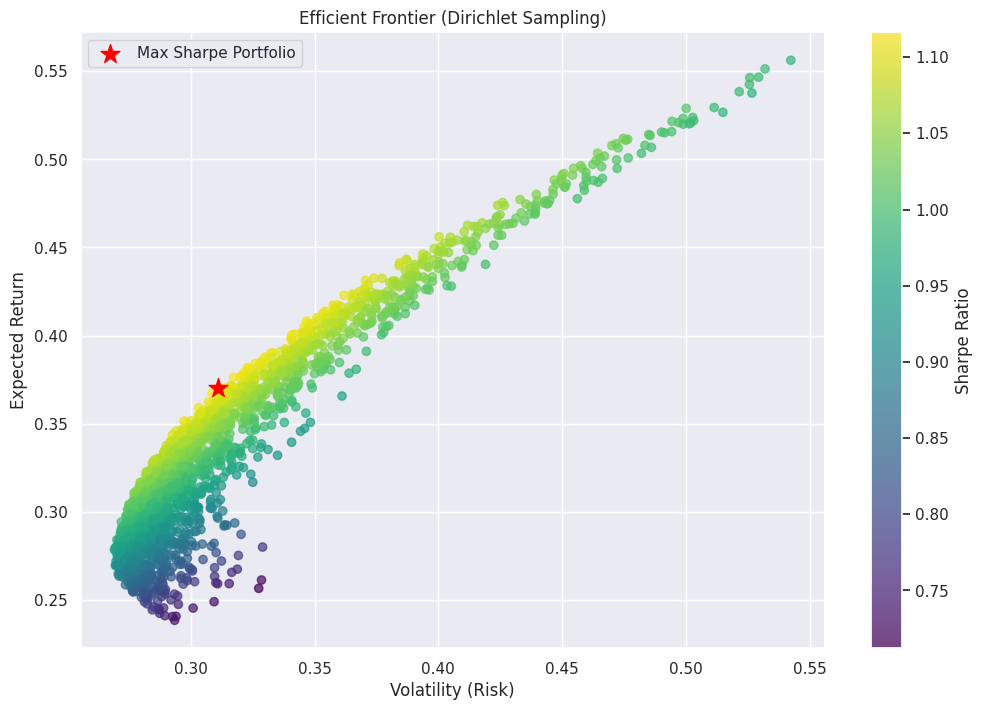

Best Portfolio is Portfolio Return          0.370303
Portfolio Risk            0.310842
Portfolio Sharpe Ratio    1.116366
Name: 432, dtype: float64
Most Optimum weights are [0.34427654 0.0084919  0.00204272 0.40894286 0.236246  ]


In [6]:
results_df,rf = generate_efficient_frontier(r,risk_free)


In [7]:
results_df.sort_values(by = 'Portfolio Sharpe Ratio',ascending = False)


,Portfolio Return,Portfolio Risk,Portfolio Sharpe Ratio,Weights
432,0.370303,0.310842,1.116366,"[0.34427653805532843, 0.008491895891816707, 0...."
1215,0.367434,0.308570,1.115286,"[0.38304144059210676, 0.014185846703394395, 0...."
836,0.376348,0.317224,1.112962,"[0.33985817756520403, 0.040969470262842304, 0...."
743,0.381825,0.322991,1.110046,"[0.19873587274173055, 0.01041014255358112, 0.0..."
1088,0.408210,0.346777,1.109995,"[0.3840749821394575, 0.0416160808283125, 0.016..."
...,...,...,...,...
1005,0.245218,0.300902,0.737542,"[0.020803545410146687, 0.6039382983786213, 0.3..."
686,0.238316,0.293406,0.732861,"[2.565024881138177e-05, 0.08696802543827845, 0..."
404,0.248852,0.309381,0.729076,"[0.01157668792928938, 0.7002092318330753, 0.26..."
242,0.261170,0.328537,0.724061,"[0.016122208425352502, 0.8665501723257141, 0.0..."


We can see from the above that even though top 5 sharpe ratios are identical, their weights vary a lot because assets can be these assets are tech assets which are identical in nature, therefore they have a high correlation and they can be used interchangibly.

## Capital Market Line
CML line is the line tangent to efficient Frontier, it combines risky asset with the asset that has the best Sharpe ratio on Efficient frontier to get the asset that has risk return characterisitics that is better than any portfolio on Efficient Frontier

In [8]:
best_pf = results_df.sort_values(by = 'Portfolio Sharpe Ratio',ascending = False)
best_pf = best_pf.iloc[0]
best_pf

,432
Portfolio Return,0.370303
Portfolio Risk,0.310842
Portfolio Sharpe Ratio,1.116366
Weights,"[0.34427653805532843, 0.008491895891816707, 0...."


Sharpe Ratio of tangency pf is 1.116365865625664


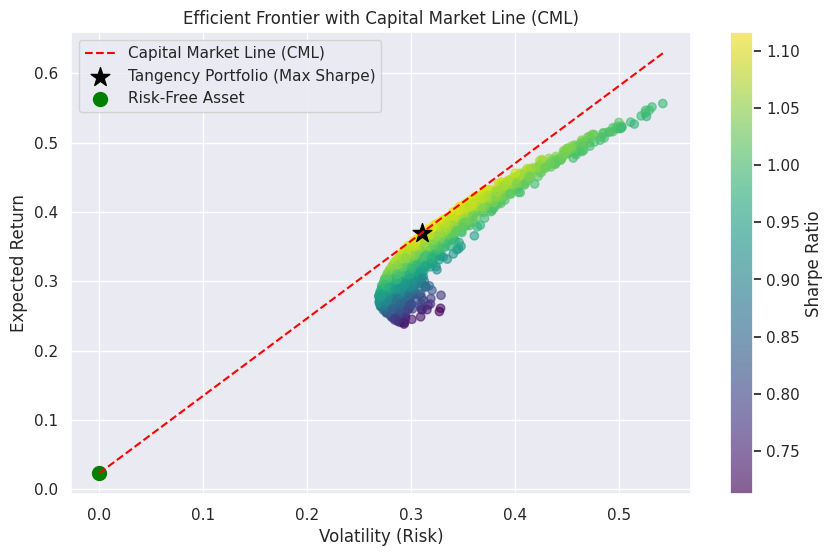

In [9]:
tangency_return = float(best_pf['Portfolio Return'])
tangency_risk = float(best_pf['Portfolio Risk'])

#Capital Market line slope
cml_slope = (tangency_return - rf) / tangency_risk
print('Sharpe Ratio of tangency pf is',cml_slope)

#Define X axis for CML line
x_cml = np.linspace(0,max(results_df['Portfolio Risk']),100)

#CML formula = rf + cml_slope * tangency risk
y_cml = rf + cml_slope * x_cml

# Plot efficient frontier
plt.figure(figsize=(10, 6))
scatter = plt.scatter(results_df['Portfolio Risk'], results_df['Portfolio Return'],
                      c=results_df['Portfolio Sharpe Ratio'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Sharpe Ratio')

# Plot Capital Market Line
plt.plot(x_cml, y_cml, color='red', linestyle='--', label='Capital Market Line (CML)')

# Mark the tangency (max Sharpe) portfolio
plt.scatter(tangency_risk, tangency_return, color='black', marker='*', s=200, label='Tangency Portfolio (Max Sharpe)')

# Risk-free rate point
plt.scatter(0, rf, color='green', marker='o', s=100, label='Risk-Free Asset')

# Labels and grid
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier with Capital Market Line (CML)')
plt.legend()
plt.grid(True)
plt.show()


We can see that Sharpe ratio that we get from CML slope, is a bit more than our highest sharpe ratio which confirms the fact that to get the most optimal portfolio we can combine our highest sharpe PF with risk free asset and construct CML line.

## Value at Risk & Expected Shortfall

VAR focuses on downside risk, allows us to quantify how much money can we lose for a given time period and confidence interval. More theory on VAR is covered in my personal notes, VAR can be calculated using 3 ways :-

1) Historical Method <br>
2) Parametric Method <br>
3) Monte Carlo Simulation

VAR mostly tells us what is our maximum loss for a given confidence interval but it does not tell us what will be our expected loss, we take help of expected shortfall for this. ES gives us average loss once VAR is breached we will see below how to use various methods to calculate ES.

### VAR using Historical Method

This is one of the most intuitive and easiest ways to calculate VAR, Just arrange the historical Returns in increasing order (lowest to highest), now suppose you want to calculate VAR with 95% confidence level, therefore simply take 5th percentile value and that will be your VAR. This method is non parametric method that is this does not assume anything about the distribution.

This method implies past performance = Future performance and also implies that each day in the past contributes equally to the VAR, you can do little modification and give more weightage to recent days.

In [10]:
btcusd = yf.download('BTC-USD',start = '2015-01-01', end = '2025-01-01', auto_adjust = False)['Adj Close']
btcusd

[*********************100%***********************]  1 of 1 completed


Ticker,BTC-USD
Date,
2015-01-01,314.248993
2015-01-02,315.032013
2015-01-03,281.082001
2015-01-04,264.195007
2015-01-05,274.473999
...,...
2024-12-27,94164.859375
2024-12-28,95163.929688
2024-12-29,93530.226562


In [11]:
btc_returns = ((btcusd - btcusd.shift(1)) / btcusd.shift(1)).dropna()
btc_returns.index = pd.to_datetime(btc_returns.index.date)
btc_returns


Ticker,BTC-USD
2015-01-02,0.002492
2015-01-03,-0.107767
2015-01-04,-0.060079
2015-01-05,0.038907
2015-01-06,0.042682
...,...
2024-12-27,-0.017022
2024-12-28,0.010610
2024-12-29,-0.017167
2024-12-30,-0.009484


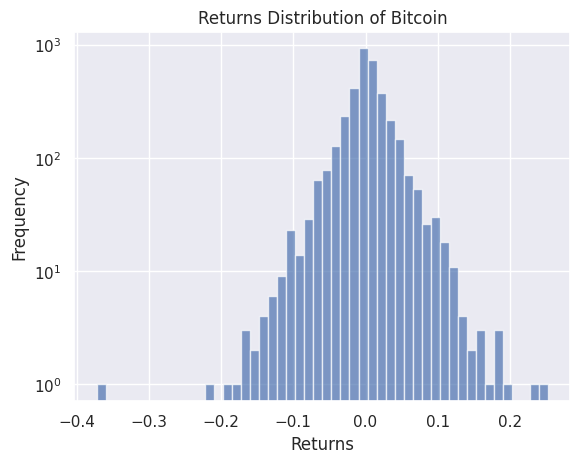

In [12]:
plt.hist(btc_returns, bins =50, log = True,alpha = 0.7)
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.title('Returns Distribution of Bitcoin')
plt.show()

In [13]:
def getHistoricalVar(returns, confidenceLevel):
  #np.quantile basically arranges the returns in increasing order, then gives out that quantile value, as in here we will ask for 10th, 5th and 1st quantile value
  hist_var = np.quantile(returns, 1-confidenceLevel)
  print(f'Historical VAR for confidence {confidenceLevel} is {round(100*hist_var,3)}%')

getHistoricalVar(btc_returns,0.90)
getHistoricalVar(btc_returns,0.95)
getHistoricalVar(btc_returns,0.99)

Historical VAR for confidence 0.9 is -3.468%
Historical VAR for confidence 0.95 is -5.591%
Historical VAR for confidence 0.99 is -10.234%


We can see here as our confidence interval increases our VAR or % returns keep on going more negative, think of it like this we are 90% sure that our maximum 1 Day loss will be -3.7%, we are 95% sure that our maximum 1 day loss will be -6% and we are 99% sure that our maximum one day loss will be -10.6%

### Exepected Shortfall using Historical method

Calculating ES using historical method is very easy, ES calculates average loss in the tail of distribution beyond the VAR threshold.

In [14]:
def gethistoricalES(returns, confidencelevel):
  Var = np.quantile(returns, 1-confidencelevel)
  es = returns[returns <= Var].mean()
  print(f'Historical VAR for confidence {confidencelevel} is {round(100*float(es),3)}%')

gethistoricalES(btc_returns,0.90)
gethistoricalES(btc_returns,0.95)
gethistoricalES(btc_returns,0.99)

Historical VAR for confidence 0.9 is -6.414%
Historical VAR for confidence 0.95 is -8.49%
Historical VAR for confidence 0.99 is -13.655%


/tmp/ipython-input-14-2512186022.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f'Historical VAR for confidence {confidencelevel} is {round(100*float(es),3)}%')
/tmp/ipython-input-14-2512186022.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f'Historical VAR for confidence {confidencelevel} is {round(100*float(es),3)}%')
/tmp/ipython-input-14-2512186022.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f'Historical VAR for confidence {confidencelevel} is {round(100*float(es),3)}%')


From the above we can see how easy it is to use historical Method to generate Expected Shortfall

### Parametric VAR using Normal distribution

Parametric Var is given by Var = mean + Zvalue * sigma </br>
Parametric approach assumes that:- </br>
1) Data is normally distributed. </br> 2) Mean, Variance and Covariance should remain constant. (You can see in the formula we take constant values) </br> 3) It only works for linear Payoff and does not work for non linear Payoffs like options. </br> While we hardly get this kind of data in the market, parametric VAR is still very important because it helps us to sense check our other Var numbers and at times can be used to calculate quick VAR numbers.

In [15]:
def parametric_var(returns,confidencelevel):
  mean = returns.mean()
  std = returns.std()
  z = stats.norm.ppf(1-confidencelevel)
  parametric_var = mean + z * std
  print(f'Parametric Normal Var for confidence{confidencelevel} is {round(float(parametric_var)*100,3)}%')

parametric_var(btc_returns,0.90)
parametric_var(btc_returns,0.95)
parametric_var(btc_returns,0.99)

Parametric Normal Var for confidence0.9 is -4.426%
Parametric Normal Var for confidence0.95 is -5.744%
Parametric Normal Var for confidence0.99 is -8.216%


/tmp/ipython-input-15-947310605.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f'Parametric Normal Var for confidence{confidencelevel} is {round(float(parametric_var)*100,3)}%')


### Expected Shortfall using Parametric method

The formula to calculate Expected shortfall using parametric Method is given below

$$
\text{ES}_\alpha = \mu + \sigma \cdot \frac{\phi(z_\alpha)}{1 - \alpha}
$$
- $\mu$: Mean of returns  
- $\sigma$: Standard deviation of returns  
- $z_\alpha$: Z-score at confidence level $\alpha$ (e.g., 1.645 for 95%)  
- $\phi(z_\alpha)$: Standard normal PDF at $z_\alpha$  
- $\alpha$: Confidence level (e.g., 0.95)

The Assumptions behind parametric ES is same as Parametric VAR


In [16]:
def parametric_ES(returns,confidencelevel):
  mean = returns.mean()
  std = returns.std()
  z = stats.norm.ppf(1-confidencelevel)
  z_pdf = stats.norm.pdf(z)
  ES = mean + std *(z_pdf/(1-confidencelevel))
  return float(ES)

print('Parametric ES for confidence level of 90% is',parametric_ES(btc_returns,0.90)*100,'%')
print('Parametric ES for confidence level of 95% is',parametric_ES(btc_returns,0.95)*100,'%')
print('Parametric ES for confidence level of 99% is',parametric_ES(btc_returns,0.99)*100,'%')

Parametric ES for confidence level of 90% is 6.588640033459603 %
Parametric ES for confidence level of 95% is 7.704936914662537 %
Parametric ES for confidence level of 99% is 9.89052677166334 %


/tmp/ipython-input-16-1225634676.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(ES)


### Var using Monte Carlo Simulation

For VAR using Monte carlo simulation, we will first simulate the Bitcoin's path using Geometric Brownian Motion, then we will then arrange the simulated P&L and generate VAR the same way as we did in historical Method

In [20]:
#We will calculate log returns first

btc_log_returns = np.log(btcusd / btcusd.shift(1)).dropna()
btc_log_returns.index = pd.to_datetime(btc_log_returns.index.date)
btc_log_returns

Ticker,BTC-USD
2015-01-02,0.002489
2015-01-03,-0.114028
2015-01-04,-0.061959
2015-01-05,0.038169
2015-01-06,0.041796
...,...
2024-12-27,-0.017169
2024-12-28,0.010554
2024-12-29,-0.017316
2024-12-30,-0.009529


We use the below GBM formula to simulate the new paths,

$$
\ln\left(\frac{S(t)}{S_0}\right) = \left(\mu - \frac{1}{2} \sigma^2\right)t + \sigma W_t
$$

Here to simulate *W* we will use normal distribution, one shortcoming of this will be that normal distribution might not be able to capture the long tails of BTC that were captured in Historical Simulation

In [45]:
def simulate_btc_path(returns,T):

  #T here is number of days or 1 path for 1 simulation
  mu = returns.mean()
  sigma = returns.std()
  dt =1 # for 1 day
  simulations = 10000 #100 simulations for starting

  #generating all random numbers at once for speed where rows will show simulation1, simulation2 etc and columns will show T steps size = (simulations,T)
  z = np.random.normal(0,1,size=(simulations,T))

  #Applying GBM returns formula
  #We dont't require loop here because our Z is basically (simulations,T) where we project the scalar value of (mu - 0.5*sigma^2)+ sigma*np.sqrt(dt) across entire z
  log_returns_simulated = (mu - 0.5 * sigma**2)*dt + sigma*np.sqrt(dt)*z


  return log_returns_simulated

In [47]:
btc_log_returns.shape

(3652, 1)

In [50]:
#We take iloc here because we want scalar values for mu and sigma
return_simulation = simulate_btc_path(btc_log_returns.iloc[:,0],365)

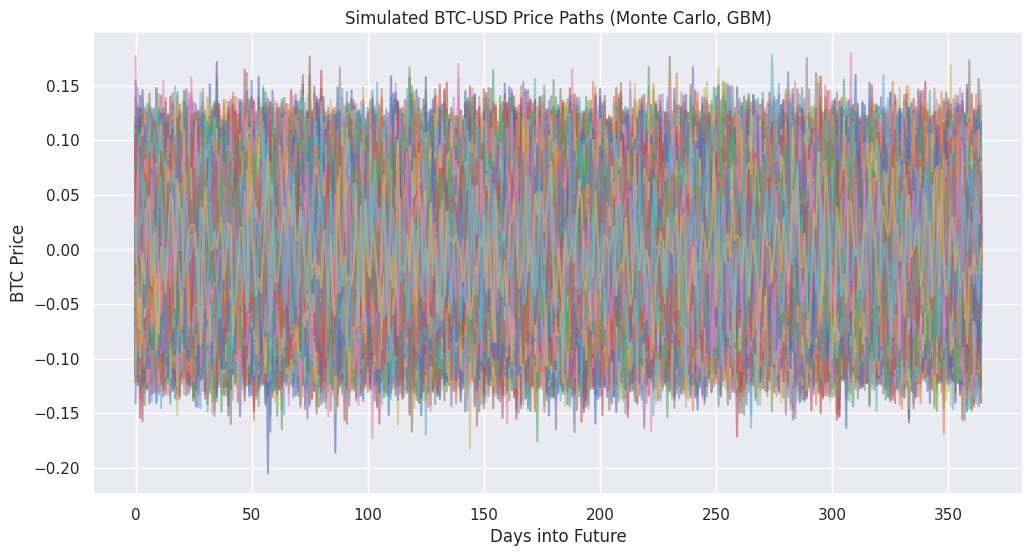

In [51]:
plt.figure(figsize=(12, 6))
plt.plot(return_simulation.T, alpha=0.6)  # Transpose to get time or steps on x-axis
plt.title("Simulated BTC-USD Price Paths (Monte Carlo, GBM)")
plt.xlabel("Days into Future")
plt.ylabel("BTC Price")
plt.grid(True)
plt.show()

In [52]:
def monte_carlo_var(simulation,confidencelevel):
  #Below you get var number for each day so what it does is across each days it will calculate the 90th or 95th percentile VAR, so you will get an array of 365 where each element will return future day's expected VAR
  #axis =1 means it will calculate 5% quantile value for each day so you will get 365 values for next 365 days
  monte_carlo_var = np.quantile(simulation,1-confidencelevel,axis=0)
  return monte_carlo_var

In [53]:
monte_carlo_var_daily = monte_carlo_var(return_simulation,0.95)*100
#We get future VAR numbers for each day
monte_carlo_var_daily

array([-5.92616644, -5.89379109, -5.97141173, -5.81312479, -5.92409598,
       -5.96984922, -5.75423095, -5.94974579, -6.06477251, -5.8837053 ,
       -5.94377061, -5.99699114, -5.85632621, -6.04750991, -6.09915086,
       -5.90035233, -5.93704379, -5.88176526, -5.99599368, -5.8966052 ,
       -5.93074253, -5.87241646, -5.91038508, -5.96128018, -6.0275515 ,
       -6.13578113, -5.86931637, -5.9353632 , -5.87829148, -5.78183192,
       -5.86773583, -6.10691168, -5.94278698, -5.9014998 , -5.96915519,
       -5.90290118, -5.85497221, -5.85487234, -6.06948836, -5.82611136,
       -5.93826354, -5.8319825 , -5.93386433, -5.98131326, -5.99094093,
       -5.90635647, -5.9393594 , -5.79783379, -6.07555327, -5.95871568,
       -5.90629703, -5.97931152, -5.86263094, -5.83898399, -5.82247967,
       -5.96468746, -5.84174928, -5.96073417, -5.86717485, -5.76218227,
       -5.94344744, -5.94416686, -6.01413958, -6.10458508, -5.95719562,
       -5.93096916, -5.82471828, -6.03423776, -5.84108516, -5.94

In [54]:
#So if you want VAR number for tomorrow you just do
monte_carlo_var_daily[0]

np.float64(-5.9261664352467225)

We can see that historical VAR was around -8.49%, where as montecarlo var for every day is around 6% (parametric Var was around 5%). This is because BTC in general must had very large drops which can lead to extreme tails. Monte carlo var assumes constant variance across each time step and the distribution for BM that we used was also normal distribution, that is why monte carlo VAR was somewhere near parametric VAR. To get more accurate results we can use t distribution that generally has fatter tails to simulate our returns or fit a GARCH model to simulate historical volatility